# 02 · Analysis

Runs every non-plotting analysis on the processed panel and ABS data produced by `01_data_preparation.ipynb`:

1. Internal QA — manual WGI file vs. V-Dem-bundled WGI (a parsing sanity check, not a paper result).
2. Stationarity-gated Granger causality — Nepal-only, primary (exit freedom -> net migration) and secondary (corruption -> remittances).
3. Pooled panel Granger causality (Dumitrescu-Hurlin-style) across all 6 countries, same two pairings.
4. Time-series forecasting + backtesting for Nepal remittances and governance.
5. Asian Barometer trust-battery reliability (Cronbach's alpha), by wave.
6. CFA + bootstrapped mediation models (the one individual-level test in this study).

This is a thin, narrated wrapper around `src/analysis.py` and `src/statistics.py` — every formula, threshold, and random seed is preserved verbatim from `nepal_south_asia_timeseries_V7.ipynb` Sections 7b, 15-20, and 21.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd

from src import analysis, config
from src.utils import setup_logging

logger = setup_logging()

panel = pd.read_csv(config.PANEL_CSV)
abs_df = pd.read_csv(config.ABS_CSV)
print("panel:", panel.shape, "| abs_df:", abs_df.shape)

panel: (210, 37) | abs_df: (19059, 33)


## Internal QA — manual WGI file vs. V-Dem-bundled WGI

V-Dem's "Full+Others" release folds in the same World Bank WGI "Estimate" series as external variables (`e_wbgi_*`), so these two should closely agree almost everywhere they both have data. A low correlation here would flag a parsing problem, not a real disagreement between governance datasets — nothing downstream cites this output directly.

In [2]:
analysis.wgi_vdem_qa_crosscheck(panel)

19:58:39 [INFO]   Government Effectiveness   vs e_wbgi_gee  : r=1.000 over 156 country-years


INFO:nepal_south_asia:  Government Effectiveness   vs e_wbgi_gee  : r=1.000 over 156 country-years


19:58:39 [INFO]   Control of Corruption      vs e_wbgi_cce  : r=1.000 over 156 country-years


INFO:nepal_south_asia:  Control of Corruption      vs e_wbgi_cce  : r=1.000 over 156 country-years


19:58:39 [INFO]   Regulatory Quality         vs e_wbgi_rqe  : r=1.000 over 156 country-years


...

19:58:39 [INFO]   Voice & Accountability     vs e_wbgi_vae  : r=1.000 over 156 country-years


INFO:nepal_south_asia:  Voice & Accountability     vs e_wbgi_vae  : r=1.000 over 156 country-years


19:58:39 [INFO]   Political Stability        vs e_wbgi_pve  : r=1.000 over 156 country-years


INFO:nepal_south_asia:  Political Stability        vs e_wbgi_pve  : r=1.000 over 156 country-years


{'GOV_WGI_GE': 1.0,
 'GOV_WGI_CC': 1.0,
 'GOV_WGI_RQ': 1.0,
 'GOV_WGI_RL': 1.0,
 'GOV_WGI_VA': 1.0,
 'GOV_WGI_PV': 1.0}

## Granger causality — Nepal, single-country

**PRIMARY:** Freedom of Foreign Movement / "exit" (`v2clfmove`) vs. net migration (`SM.POP.NETM`). **SECONDARY:** Control of Corruption vs. remittances (% GDP) — kept from V6, still relevant to the corruption narrative.

In [3]:
granger_exit_migration = analysis.granger_exit_migration_nepal(panel)

/Users/utsav/Desktop/publicpolicy/src/statistics.py:44: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  _, kpss_p, *_ = kpss(s, regression=regression, nlags="auto")
/Users/utsav/Desktop/publicpolicy/src/statistics.py:44: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  _, kpss_p, *_ = kpss(s, regression=regression, nlags="auto")
19:58:39 [INFO]   x stationarity: non-stationary (ADF p=0.0588, KPSS p=0.1)


INFO:nepal_south_asia:  x stationarity: non-stationary (ADF p=0.0588, KPSS p=0.1)


19:58:39 [INFO]   y stationarity: non-stationary (ADF p=0.4155, KPSS p=0.1)


INFO:nepal_south_asia:  y stationarity: non-stationary (ADF p=0.4155, KPSS p=0.1)


19:58:39 [INFO]   series used for the Granger test: first-differenced


...

INFO:nepal_south_asia:  x stationarity: non-stationary (ADF p=0.4155, KPSS p=0.1)


19:58:39 [INFO]   y stationarity: non-stationary (ADF p=0.0588, KPSS p=0.1)


INFO:nepal_south_asia:  y stationarity: non-stationary (ADF p=0.0588, KPSS p=0.1)


19:58:39 [INFO]   series used for the Granger test: first-differenced


INFO:nepal_south_asia:  series used for the Granger test: first-differenced


In [4]:
granger_corruption_remittances = analysis.granger_corruption_remittances_nepal(panel)

19:58:39 [INFO]   x stationarity: non-stationary (ADF p=0.965, KPSS p=0.0236)


INFO:nepal_south_asia:  x stationarity: non-stationary (ADF p=0.965, KPSS p=0.0236)


19:58:39 [INFO]   y stationarity: non-stationary (ADF p=0.7637, KPSS p=0.0199)


INFO:nepal_south_asia:  y stationarity: non-stationary (ADF p=0.7637, KPSS p=0.0199)


19:58:39 [INFO]   series used for the Granger test: first-differenced


...

INFO:nepal_south_asia:  x stationarity: non-stationary (ADF p=0.7637, KPSS p=0.0199)


19:58:39 [INFO]   y stationarity: non-stationary (ADF p=0.965, KPSS p=0.0236)


INFO:nepal_south_asia:  y stationarity: non-stationary (ADF p=0.965, KPSS p=0.0236)


19:58:39 [INFO]   series used for the Granger test: first-differenced


INFO:nepal_south_asia:  series used for the Granger test: first-differenced


## Panel (pooled) Granger causality — Dumitrescu-Hurlin-style

Same two pairings, pooled across all 6 countries, with both the classical asymptotic Z-bar p-value and a circular-shift bootstrap empirical p-value (the one to trust at this sample size).

In [5]:
panel_granger_exit_migration = analysis.panel_granger_exit_migration(panel)

/Users/utsav/Desktop/publicpolicy/src/statistics.py:44: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  _, kpss_p, *_ = kpss(s, regression=regression, nlags="auto")
/Users/utsav/Desktop/publicpolicy/src/statistics.py:44: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  _, kpss_p, *_ = kpss(s, regression=regression, nlags="auto")
/Users/utsav/Desktop/publicpolicy/src/statistics.py:44: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  _, kpss_p, *_ = kpss(s, regression=regression, nlags="auto")
/Users/utsav/Desktop/publicpolicy/src/statistics.py:44: InterpolationWarning: The test statistic is outside of the range of p-values available

In [6]:
panel_granger_corruption_remittances = analysis.panel_granger_corruption_remittances(panel)

/Users/utsav/Desktop/publicpolicy/src/statistics.py:44: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  _, kpss_p, *_ = kpss(s, regression=regression, nlags="auto")
/Users/utsav/Desktop/publicpolicy/src/statistics.py:44: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  _, kpss_p, *_ = kpss(s, regression=regression, nlags="auto")
/Users/utsav/Desktop/publicpolicy/src/statistics.py:44: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  _, kpss_p, *_ = kpss(s, regression=regression, nlags="auto")
/Users/utsav/Desktop/publicpolicy/src/statistics.py:44: InterpolationWarning: The test statistic is outside of the range of p-values available

## Forecasting + backtesting

Three models (linear trend, Holt, small-grid ARIMA) for Nepal remittances (% GDP) and Government Effectiveness, each backtested against the last 5 held-out years. The number to quote in the paper is the **linear-trend R²** (historical-fit quality), not the forward forecast — see notebook Section 17.

In [7]:
nepal = panel[panel.iso3 == config.FOCAL].set_index("year").sort_index()

remittances_results = analysis.forecast_series_with_backtest(
    nepal["BX.TRF.PWKR.DT.GD.ZS"].dropna(), horizon=5, holdout=5
)
print(f"Remittances linear-trend R^2 = {remittances_results['linear_trend']['model'].rsquared:.3f}")
print(f"Best ARIMA order = {remittances_results['arima']['order']}")
remittances_results["backtest"][1] if remittances_results["backtest"] else None

/Users/utsav/Desktop/publicpolicy/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/utsav/Desktop/publicpolicy/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/utsav/Desktop/publicpolicy/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/utsav/Desktop/publicpolicy/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starti

Remittances linear-trend R^2 = 0.845
Best ARIMA order = (0, 1, 1)


,mean_abs_pct_error,coverage,n_years_tested
model,,,
"ARIMA(0, 1, 1)",6.132,1.0,5
Holt,10.160,NaN,5
Linear trend,38.637,0.2,5


In [8]:
governance_results = analysis.forecast_series_with_backtest(
    nepal["GOV_WGI_GE"].dropna(), horizon=5, holdout=5
)
print(f"Governance linear-trend R^2 = {governance_results['linear_trend']['model'].rsquared:.3f}")
print(f"Best ARIMA order = {governance_results['arima']['order']}")
governance_results["backtest"][1] if governance_results["backtest"] else None

Governance linear-trend R^2 = 0.074
Best ARIMA order = (0, 1, 2)


,mean_abs_pct_error,coverage,n_years_tested
model,,,
"ARIMA(0, 1, 1)",3.660,1.0,5
Holt,6.343,NaN,5
Linear trend,6.299,1.0,5


## Asian Barometer trust-battery reliability

Cronbach's alpha for the institutional-trust items, per wave.

In [9]:
abs_trust_reliability = analysis.abs_trust_reliability(abs_df)

19:58:51 [INFO]   wave 2005: alpha=0.888 over 9 items (n=4712 complete respondents)


INFO:nepal_south_asia:  wave 2005: alpha=0.888 over 9 items (n=4712 complete respondents)


19:58:51 [INFO]   wave 2013: alpha=0.870 over 12 items (n=3069 complete respondents)


INFO:nepal_south_asia:  wave 2013: alpha=0.870 over 12 items (n=3069 complete respondents)


## Mediation — CFA + bootstrapped indirect effect

The one individual-level test in this study: does perceived condition -> institutional trust -> regime preference / satisfaction with democracy hold up under a bootstrapped CFA/path model? Run Nepal-only (primary outcome: regime preference; robustness: satisfaction with democracy) and pooled across all 5 surveyed countries (RQ4).

19:58:51 [INFO] === Nepal-only -- Wave 2005, outcome=regime_preference: 562 complete respondents across 9 trust items ===


INFO:nepal_south_asia:=== Nepal-only -- Wave 2005, outcome=regime_preference: 562 complete respondents across 9 trust items ===


19:58:57 [INFO]   indirect effect (perceived condition -> Trust -> regime_preference): 0.018, 95% CI [0.004, 0.036], significant=True


INFO:nepal_south_asia:  indirect effect (perceived condition -> Trust -> regime_preference): 0.018, 95% CI [0.004, 0.036], significant=True


19:58:58 [INFO] === Nepal-only -- Wave 2013, outcome=regime_preference: 1090 complete respondents across 6 trust items ===


INFO:nepal_south_asia:=== Nepal-only -- Wave 2013, outcome=regime_preference: 1090 complete respondents across 6 trust items ===


19:59:02 [INFO]   indirect effect (perceived condition -> Trust -> regime_preference): 0.011, 95% CI [-0.000, 0.024], significant=False


INFO:nepal_south_asia:  indirect effect (perceived condition -> Trust -> regime_preference): 0.011, 95% CI [-0.000, 0.024], significant=False


19:59:02 [INFO] Nepal-only (regime_preference) across-wave check: same direction in both waves = True, significant in both waves = False.


INFO:nepal_south_asia:Nepal-only (regime_preference) across-wave check: same direction in both waves = True, significant in both waves = False.


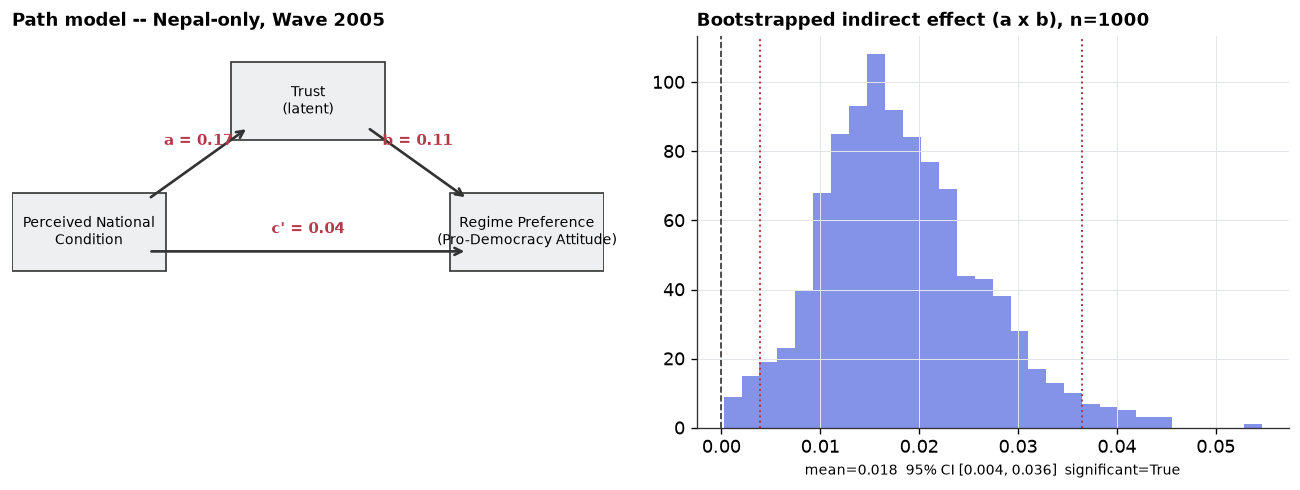

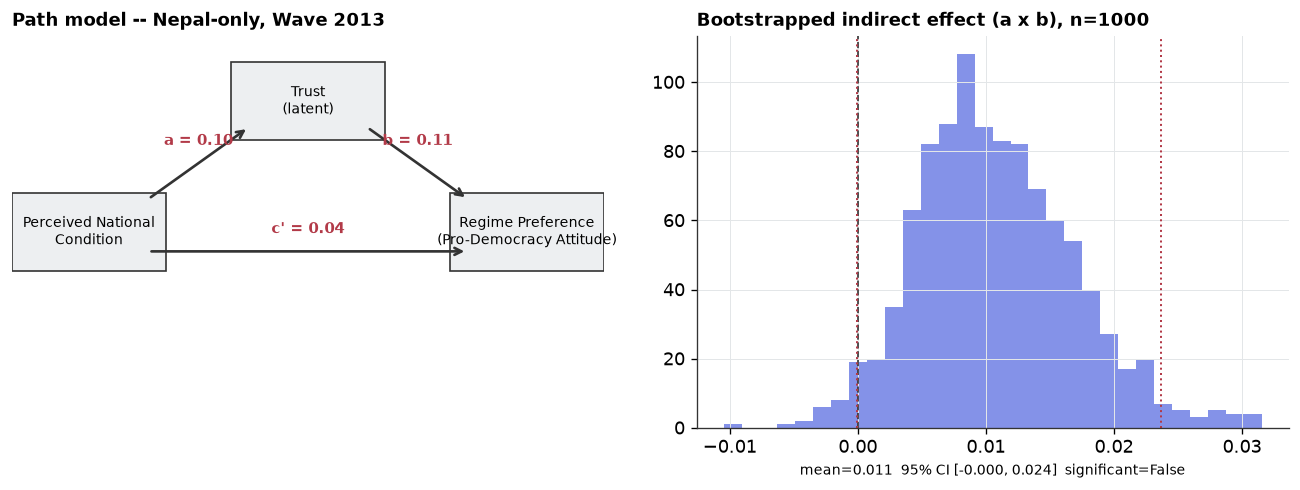

In [10]:
nepal_only = abs_df[abs_df["country"] == "Nepal"]
mediation_nepal_regime = analysis.run_mediation_for_subset(
    nepal_only, "regime_preference", "Nepal-only"
)

19:59:03 [INFO] === Nepal-only -- Wave 2005, outcome=satisfaction_democracy: 734 complete respondents across 9 trust items ===


INFO:nepal_south_asia:=== Nepal-only -- Wave 2005, outcome=satisfaction_democracy: 734 complete respondents across 9 trust items ===


19:59:10 [INFO]   indirect effect (perceived condition -> Trust -> satisfaction_democracy): 0.005, 95% CI [0.001, 0.009], significant=True


INFO:nepal_south_asia:  indirect effect (perceived condition -> Trust -> satisfaction_democracy): 0.005, 95% CI [0.001, 0.009], significant=True


19:59:10 [INFO] === Nepal-only -- Wave 2013, outcome=satisfaction_democracy: 1098 complete respondents across 6 trust items ===


INFO:nepal_south_asia:=== Nepal-only -- Wave 2013, outcome=satisfaction_democracy: 1098 complete respondents across 6 trust items ===


19:59:16 [INFO]   indirect effect (perceived condition -> Trust -> satisfaction_democracy): 0.050, 95% CI [0.025, 0.081], significant=True


INFO:nepal_south_asia:  indirect effect (perceived condition -> Trust -> satisfaction_democracy): 0.050, 95% CI [0.025, 0.081], significant=True


19:59:16 [INFO] Nepal-only (satisfaction_democracy) across-wave check: same direction in both waves = True, significant in both waves = True.


INFO:nepal_south_asia:Nepal-only (satisfaction_democracy) across-wave check: same direction in both waves = True, significant in both waves = True.


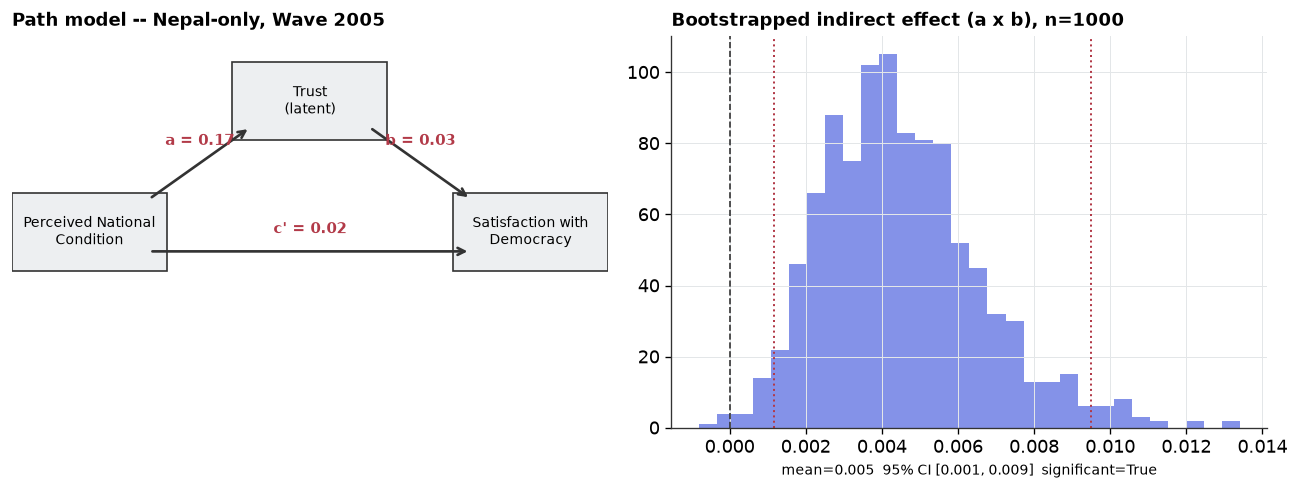

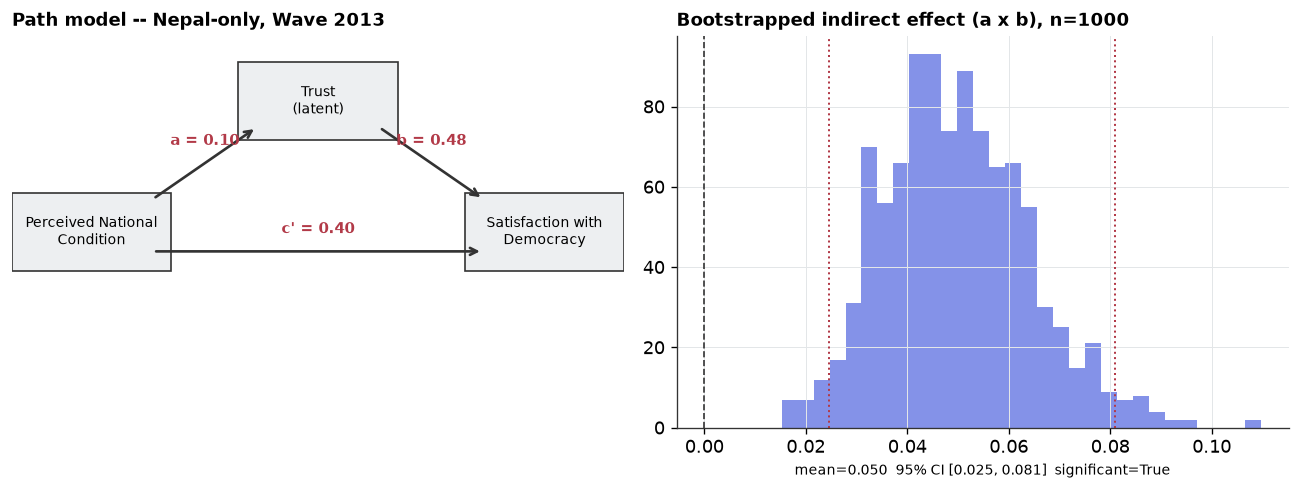

In [11]:
mediation_nepal_satisfaction = analysis.run_mediation_for_subset(
    nepal_only, "satisfaction_democracy", "Nepal-only"
)

19:59:16 [INFO] === Pooled-5-country -- Wave 2005, outcome=regime_preference: 3185 complete respondents across 9 trust items ===


INFO:nepal_south_asia:=== Pooled-5-country -- Wave 2005, outcome=regime_preference: 3185 complete respondents across 9 trust items ===


19:59:24 [INFO]   indirect effect (perceived condition -> Trust -> regime_preference): 0.020, 95% CI [0.010, 0.029], significant=True


INFO:nepal_south_asia:  indirect effect (perceived condition -> Trust -> regime_preference): 0.020, 95% CI [0.010, 0.029], significant=True


19:59:24 [INFO] === Pooled-5-country -- Wave 2013, outcome=regime_preference: 2613 complete respondents across 12 trust items ===


INFO:nepal_south_asia:=== Pooled-5-country -- Wave 2013, outcome=regime_preference: 2613 complete respondents across 12 trust items ===


19:59:35 [INFO]   indirect effect (perceived condition -> Trust -> regime_preference): 0.022, 95% CI [0.013, 0.032], significant=True


INFO:nepal_south_asia:  indirect effect (perceived condition -> Trust -> regime_preference): 0.022, 95% CI [0.013, 0.032], significant=True


19:59:36 [INFO] Pooled-5-country (regime_preference) across-wave check: same direction in both waves = True, significant in both waves = True.


INFO:nepal_south_asia:Pooled-5-country (regime_preference) across-wave check: same direction in both waves = True, significant in both waves = True.


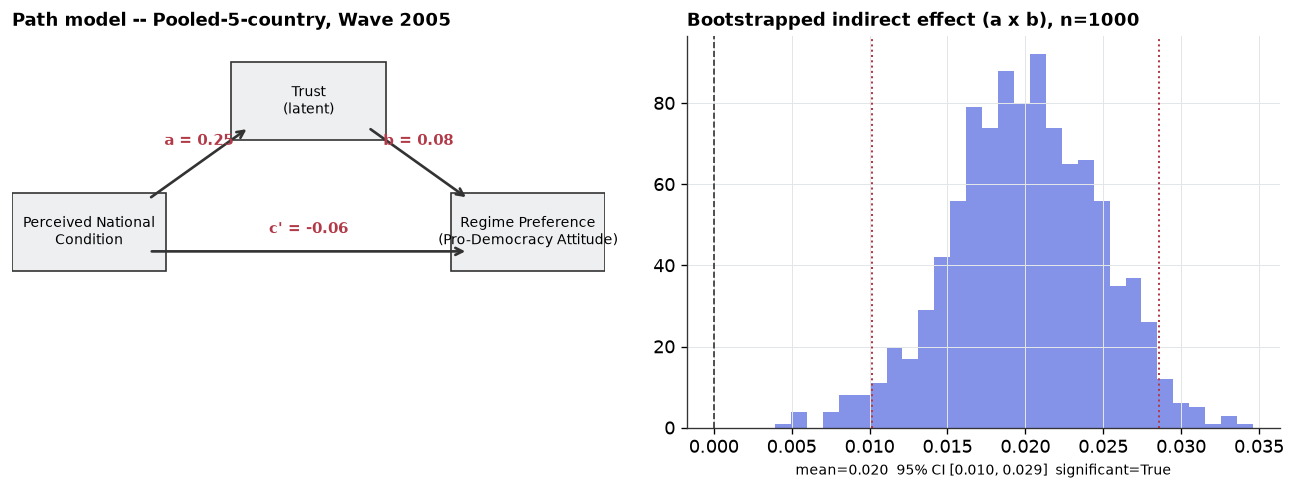

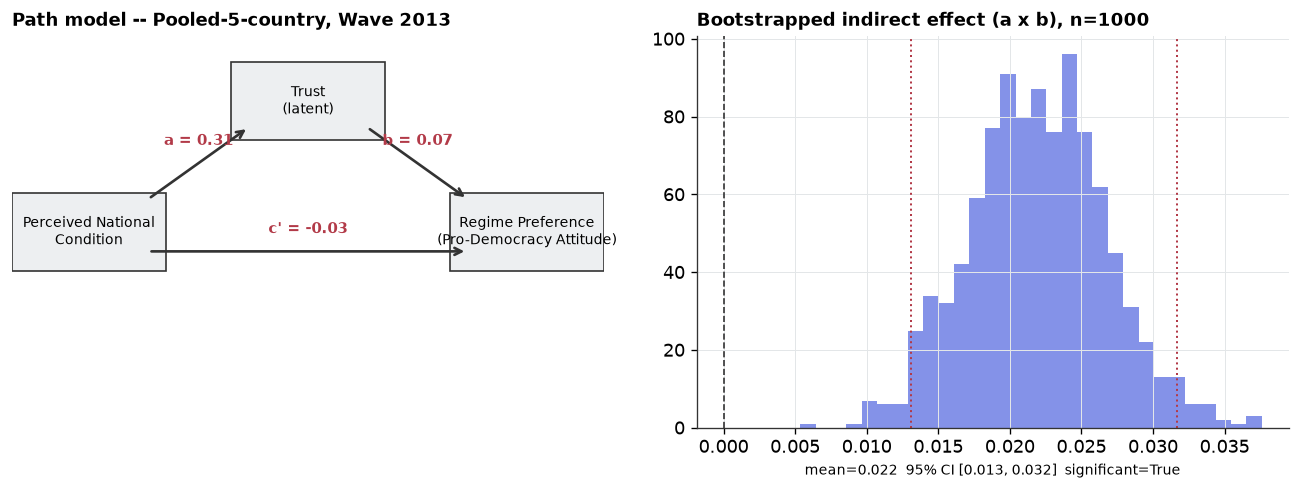

In [12]:
mediation_pooled_regime = analysis.run_mediation_for_subset(
    abs_df, "regime_preference", "Pooled-5-country"
)

Next: **`03_visualization.ipynb`** generates every named figure in the paper from this same processed data.